# Reading & Understanding Well Log Data (LAS) Using Python

# Day 1: Working with Well Log Data (LAS Files)

## Objective of Day 1

The goal of Day 1 is to get comfortable with real industry well log data and understand how Python interacts with subsurface data formats.

By the end of today, I should be able to:

- Understand what a LAS (Log ASCII Standard) file is
- Read a LAS file using Python
- Convert well log data into a workable data structure
- Perform basic data quality checks (QC)
- Understand the physical meaning of common well logs

**Note:**  
This day is about data familiarity, not analytics or modeling.

---

## Why LAS Files Matter in Oil & Gas

In the oil & gas industry, well logs are the most fundamental subsurface dataset. Almost every interpretation workflow starts from well logs.

LAS files are:

- An industry-standard format
- Used by professional software such as Petrel, Techlog, DecisionSpace, etc.
- Exchanged between service companies and operators

If you cannot handle LAS files properly, you cannot:

- Perform petrophysical analysis
- Train machine learning models on subsurface data
- Perform well–seismic tie
- Work effectively as a subsurface or reservoir analyst

---

## What is a LAS File?

A LAS (Log ASCII Standard) file is a text-based format used to store well log data along with metadata.

A typical LAS file contains the following sections:

---

### 1. Well Information Section (`~WELL`)

This section contains metadata about the well:

- Well name
- Location (latitude, longitude)
- Elevation (KB, DF, GL, etc.)
- Drilling and logging details

---

### 2. Curve Information Section (`~CURVE`)

This section describes each log recorded in the well:

- Log mnemonic (e.g., GR, RHOB, DT)
- Units
- Short description of the curve

---

### 3. ASCII Data Section (`~ASCII`)

This section contains the actual numerical log measurements:

- Depth-indexed values
- Each row corresponds to one depth level
- Each column represents a different log

Example structure:



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import lasio as ls

In [2]:
data=ls.read("/workspaces/100-Days-of-Python-for-Oil-Gas-Subsurface-Analytics/Day-01/_Gorgonichthys_1_suite3_supercombo_log_Gorgonichthys1_suite2_CMR.las")
print(data)

In [3]:
df=data.df()
df.head()

,CALI,GR,RHOB,RT,TNPH,NPHI,TCMR,CMFF
DEPTH,,,,,,,,
4145.7372,8.617,149.276,2.663,5.712,0.244,0.204,0.090,0.004
4145.5848,8.667,146.338,2.654,5.742,0.231,0.204,0.090,0.004
4145.4324,8.672,146.660,2.682,5.814,0.226,0.204,0.104,0.003
4145.2800,8.677,142.007,2.726,5.937,0.227,0.204,0.108,0.005
4145.1276,8.679,148.448,2.765,6.128,0.241,0.204,0.109,0.004


In [4]:
print("="*100)
print("The available columns in the datasets are:\n ",df.columns)
print("="*100)
print("The statsistics of the datasets are:\n ",df.describe())

The available columns in the datasets are:
  Index(['CALI', 'GR', 'RHOB', 'RT', 'TNPH', 'NPHI', 'TCMR', 'CMFF'], dtype='object')
The statsistics of the datasets are:
                CALI           GR         RHOB           RT         TNPH  \
count  1495.000000  1495.000000  1495.000000  1495.000000  1495.000000   
mean      9.223875    62.731767     2.411476   116.453977     0.119693   
std       1.289462    42.632785     0.202326   290.804450     0.078701   
min       8.292000    14.870000     1.631000     0.172000     0.001000   
25%       8.381000    29.217000     2.369000    20.534500     0.070000   
50%       8.550000    44.475000     2.447000    51.679000     0.091000   
75%       9.697000    85.634000     2.501500    86.902000     0.151000   
max      13.731000   192.391000     2.775000  1950.000000     0.404000   

              NPHI         TCMR         CMFF  
count  1494.000000  1378.000000  1378.000000  
mean      0.103089     0.132403     0.041410  
std       0.086242     0

In [5]:
df.shape

(1495, 8)

In [6]:
# Check null values in the dataframe
df.isnull().sum()

CALI      0
GR        0
RHOB      0
RT        0
TNPH      0
NPHI      1
TCMR    117
CMFF    117
dtype: int64

# Null visualisation using heatmap

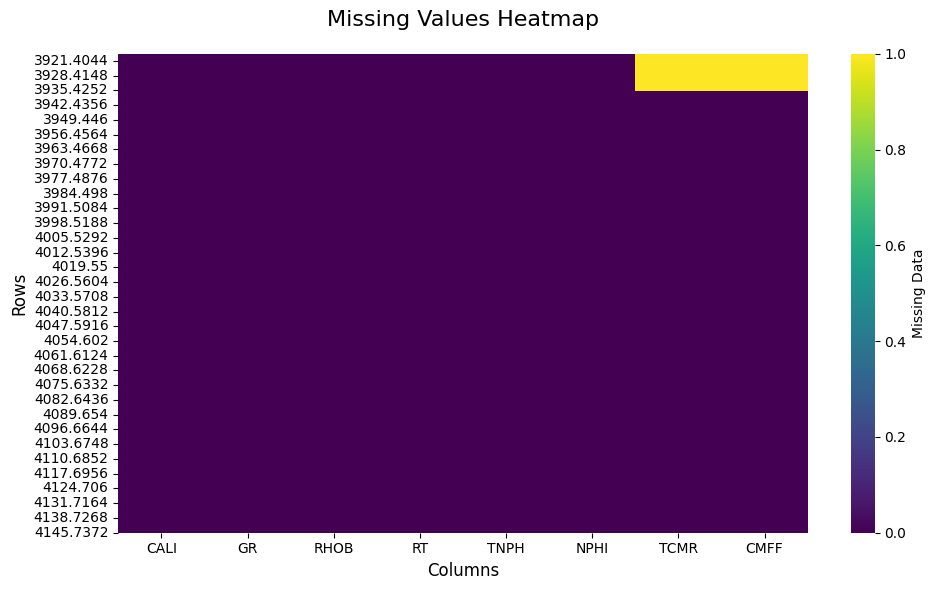

In [19]:
import seaborn as sns
null_mask=df.isnull()
plt.figure(figsize=(10,6))

sns.heatmap(null_mask, 
            cbar_kws={'label': 'Missing Data'},
            cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=16, pad=20)
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Rows', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


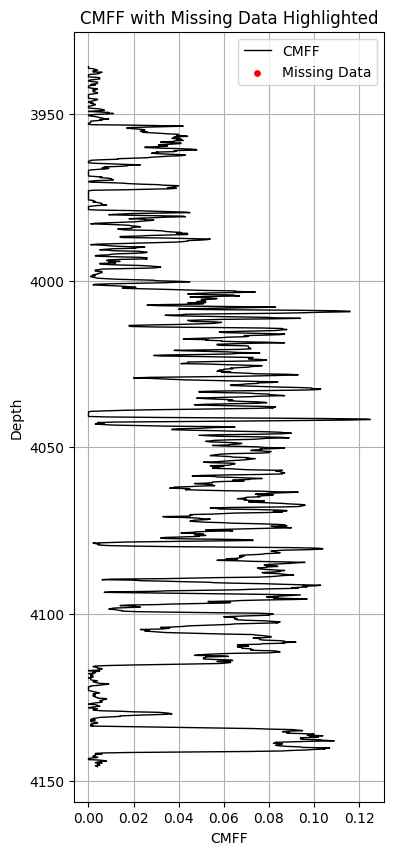

In [11]:
log = 'CMFF'

# Depth (use correct depth source)
depth = df.index   # OR df['DEPTH']

# Create mask for null values
null_mask = df[log].isna()

plt.figure(figsize=(4, 10))

# Plot actual log (only valid values)
plt.plot(df[log], depth, color='black', linewidth=1, label=log)

# Plot red dots where data is null
plt.scatter(
    df.loc[null_mask, log],
    depth[null_mask],
    color='red',
    s=15,
    label='Missing Data'
)

plt.gca().invert_yaxis()
plt.xlabel(log)
plt.ylabel('Depth')
plt.title(f'{log} with Missing Data Highlighted')
plt.legend()
plt.grid(True)

plt.show()


# Visualize all curves available in well data

In [23]:
df.columns

Index(['CALI', 'GR', 'RHOB', 'RT', 'TNPH', 'NPHI', 'TCMR', 'CMFF'], dtype='object')

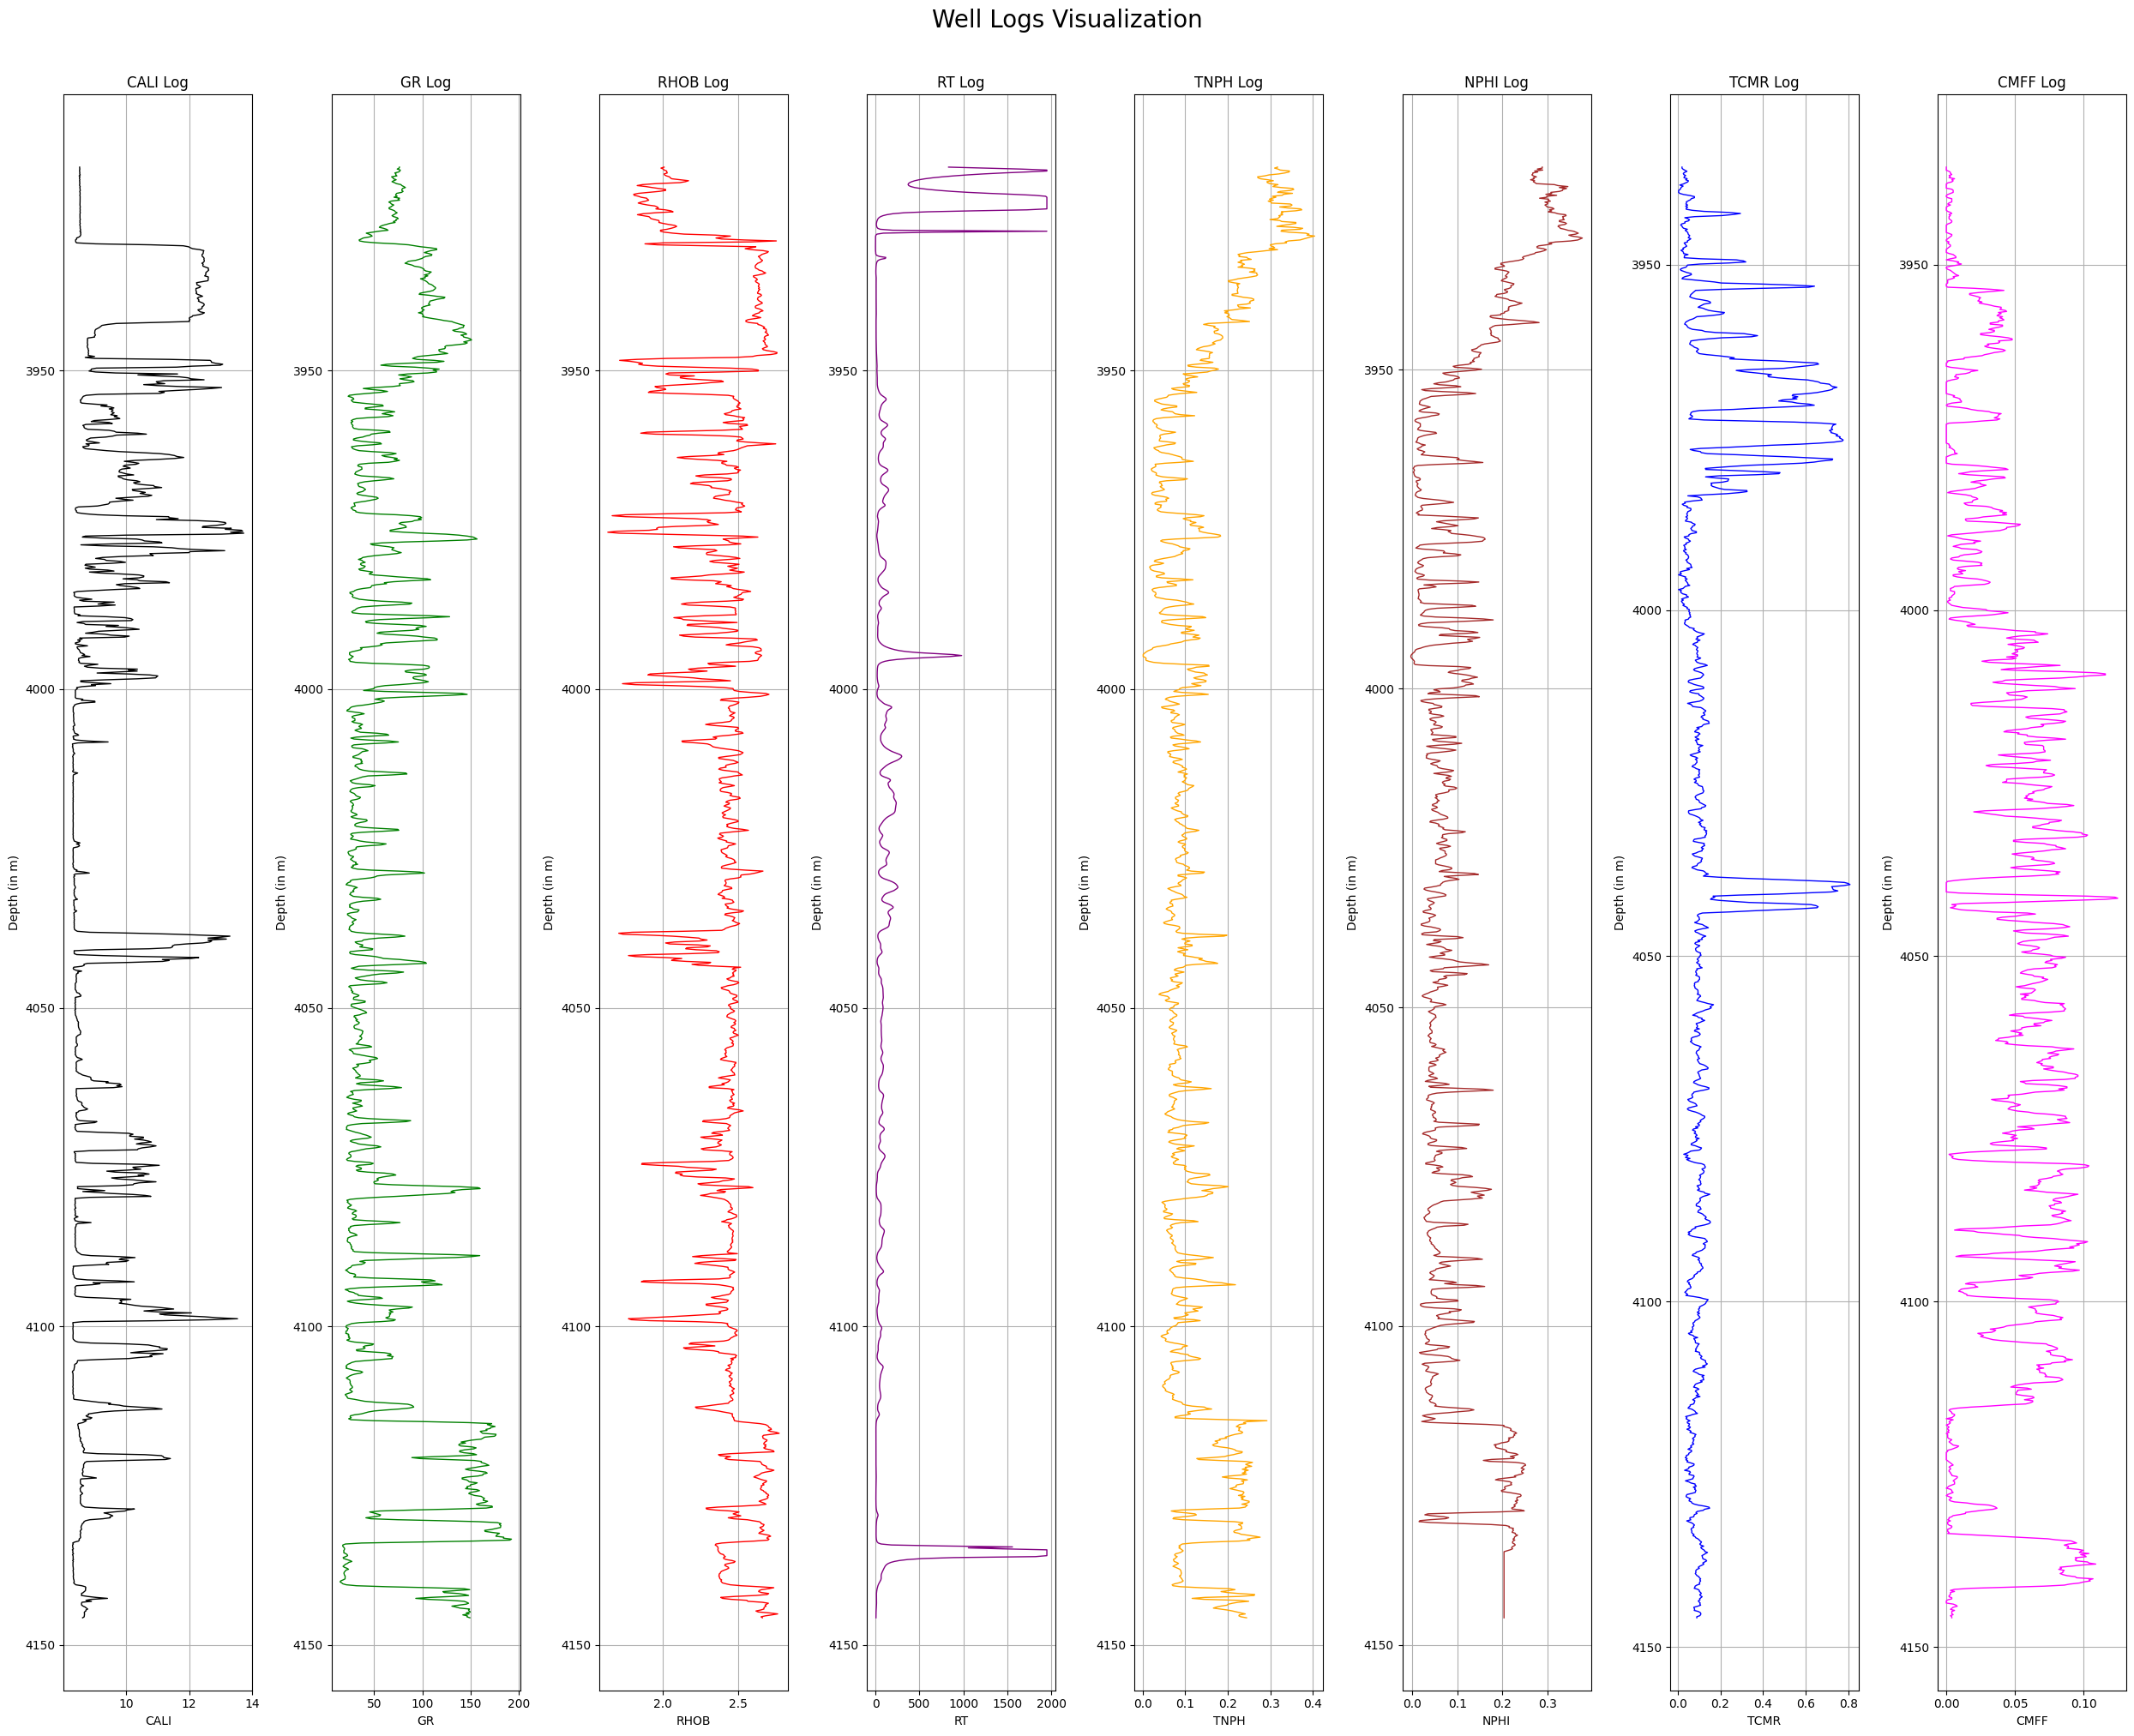

In [50]:
# All log visualization 
import matplotlib.cm as cm
logs=df.columns.tolist()
depth = df.index

# Assign individual colors to each log for better distinction

colors = [
    "black",    # e.g. GR
    "green",     # e.g. RHOB
    "red",      # e.g. NPHI
    "purple",
    "orange",
    "brown",
    "blue",
    "magenta"
]

plt.figure(figsize=(25, 20))
for i in range(len(logs)):
    plt.subplot(1,len(logs),i+1)
    plt.plot(df[logs[i]],depth,color=colors[i],linewidth=1)
    plt.xlabel(logs[i])
    plt.ylabel("Depth (in m)")
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.title(f"{logs[i]} Log")
    
plt.suptitle("Well Logs Visualization", fontsize=20, y=+1.01)
plt.tight_layout()
plt.show()


# Pair plot of each curves


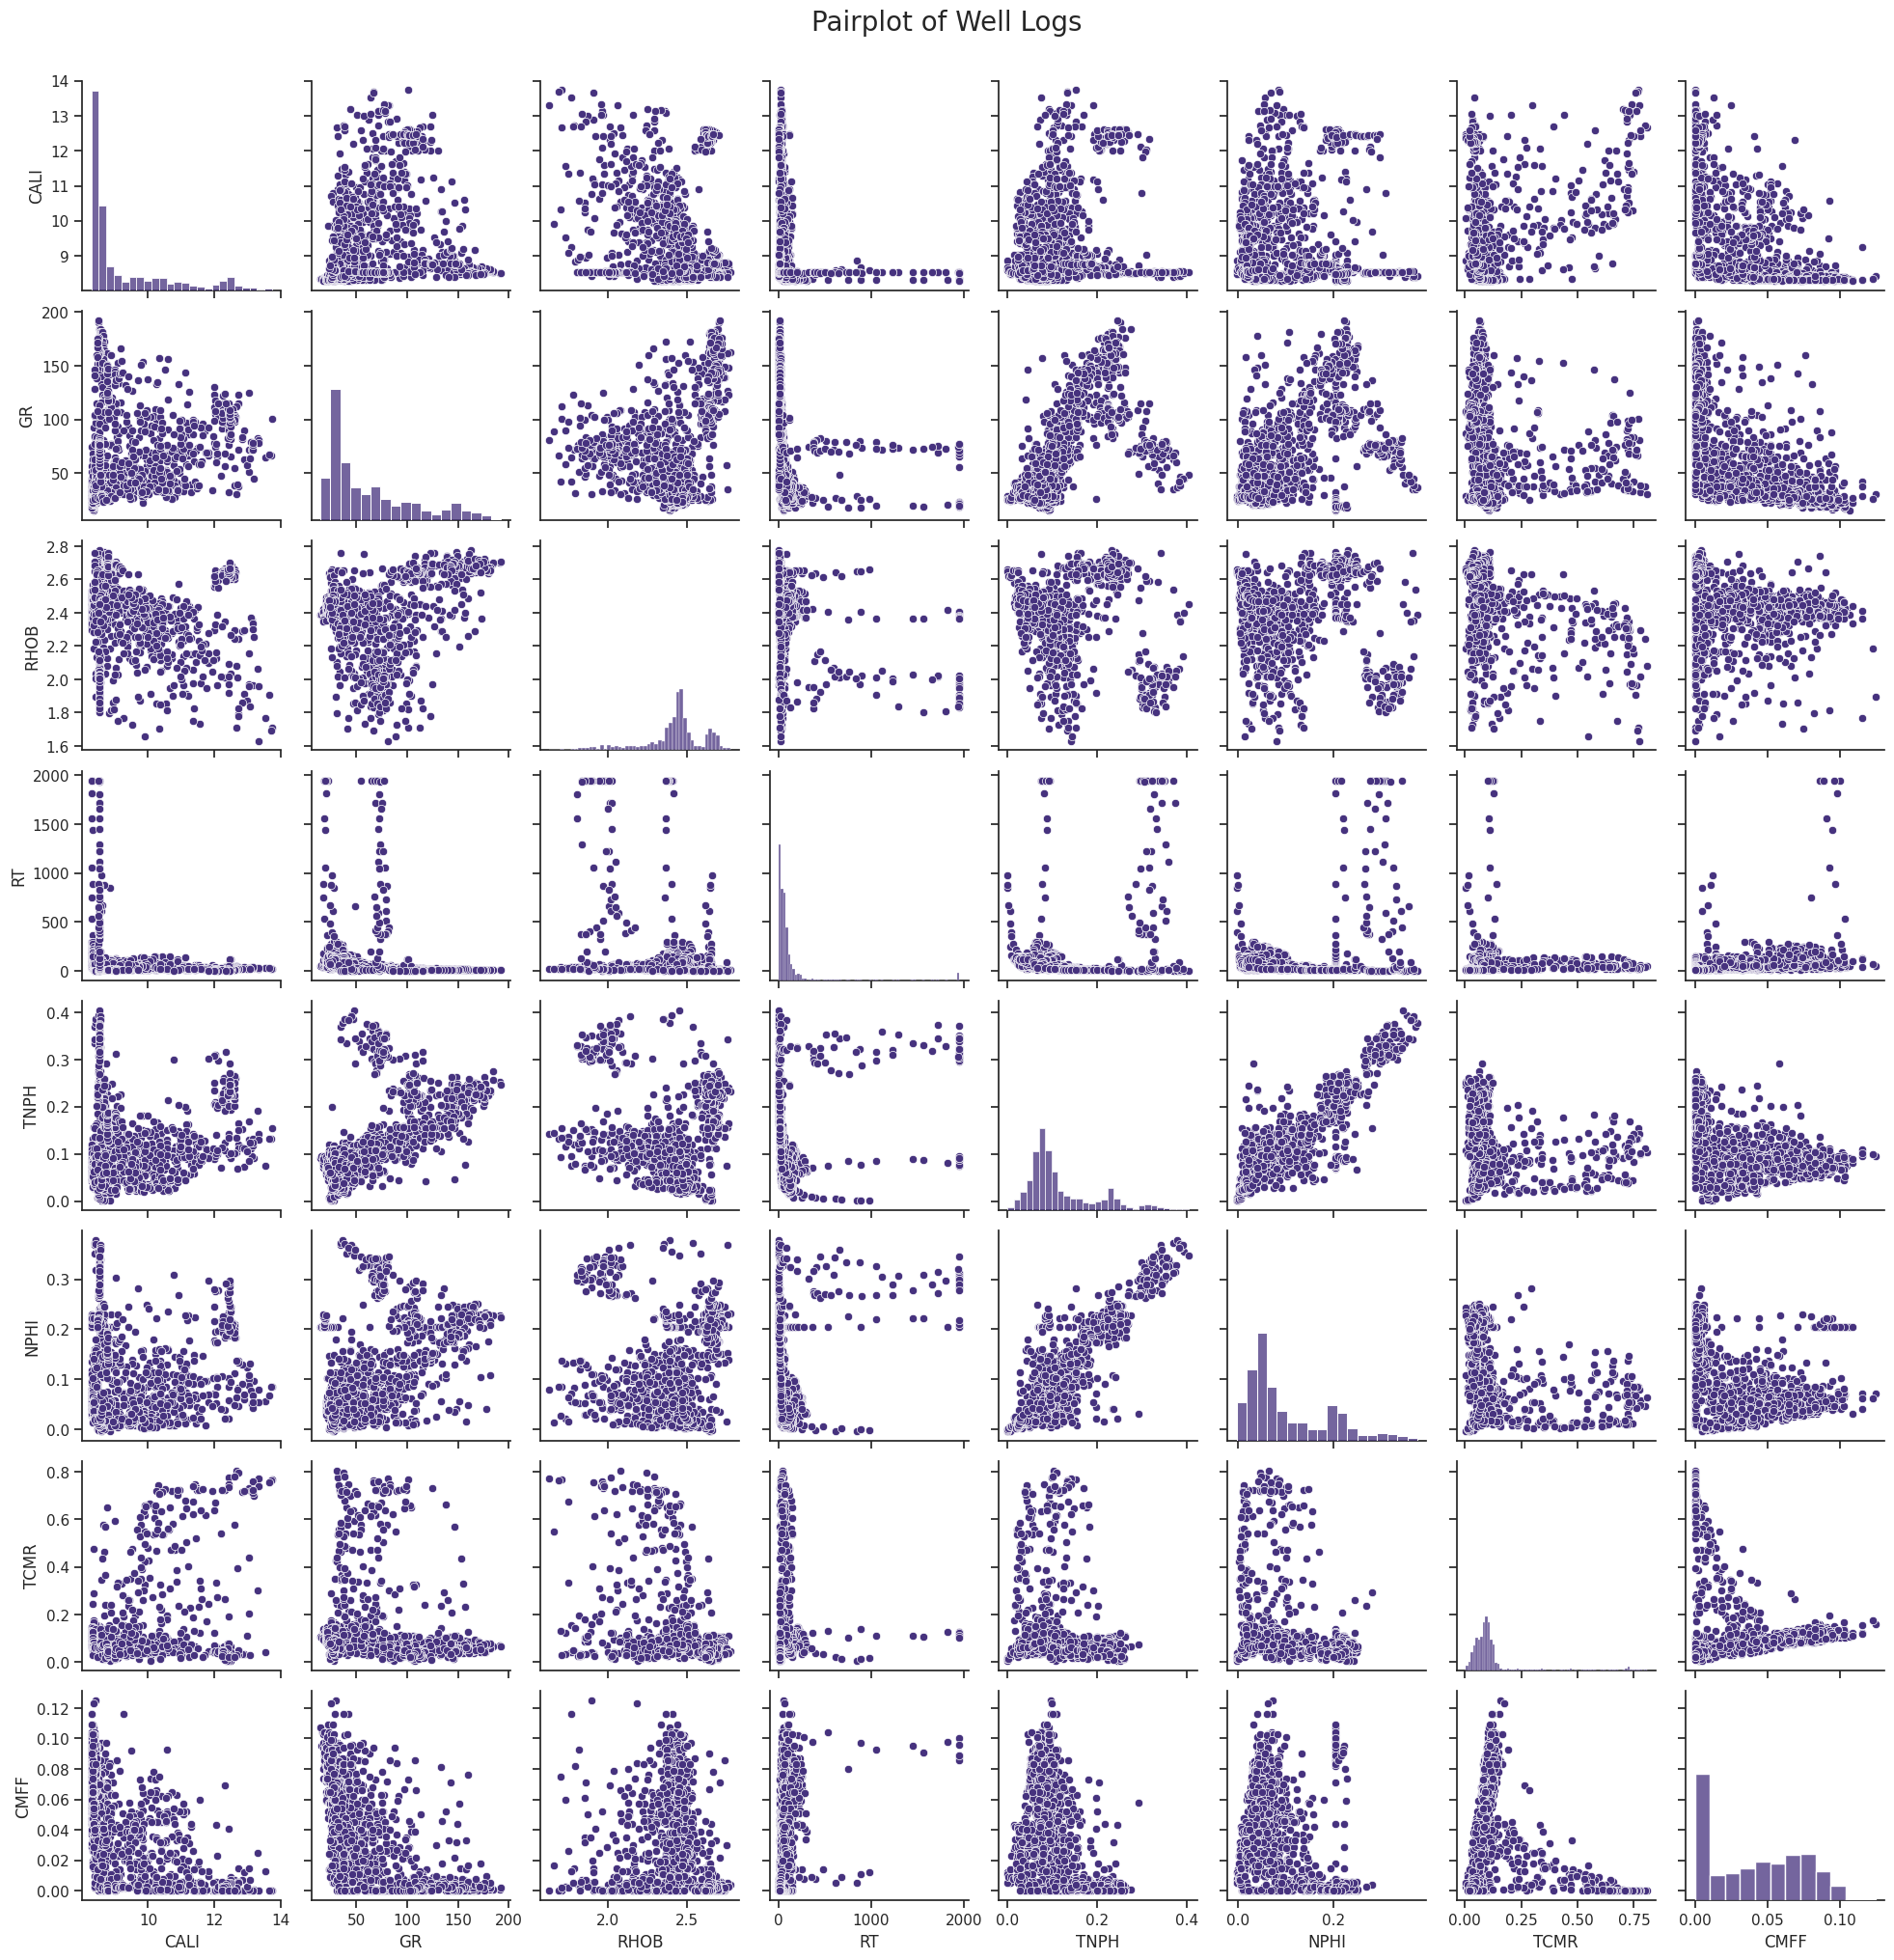

In [62]:
log_for_pair=df.columns.to_list()
sns.pairplot(df[log_for_pair])

plt.suptitle("Pairplot of Well Logs", fontsize=20, y=1.02)
plt.show()  

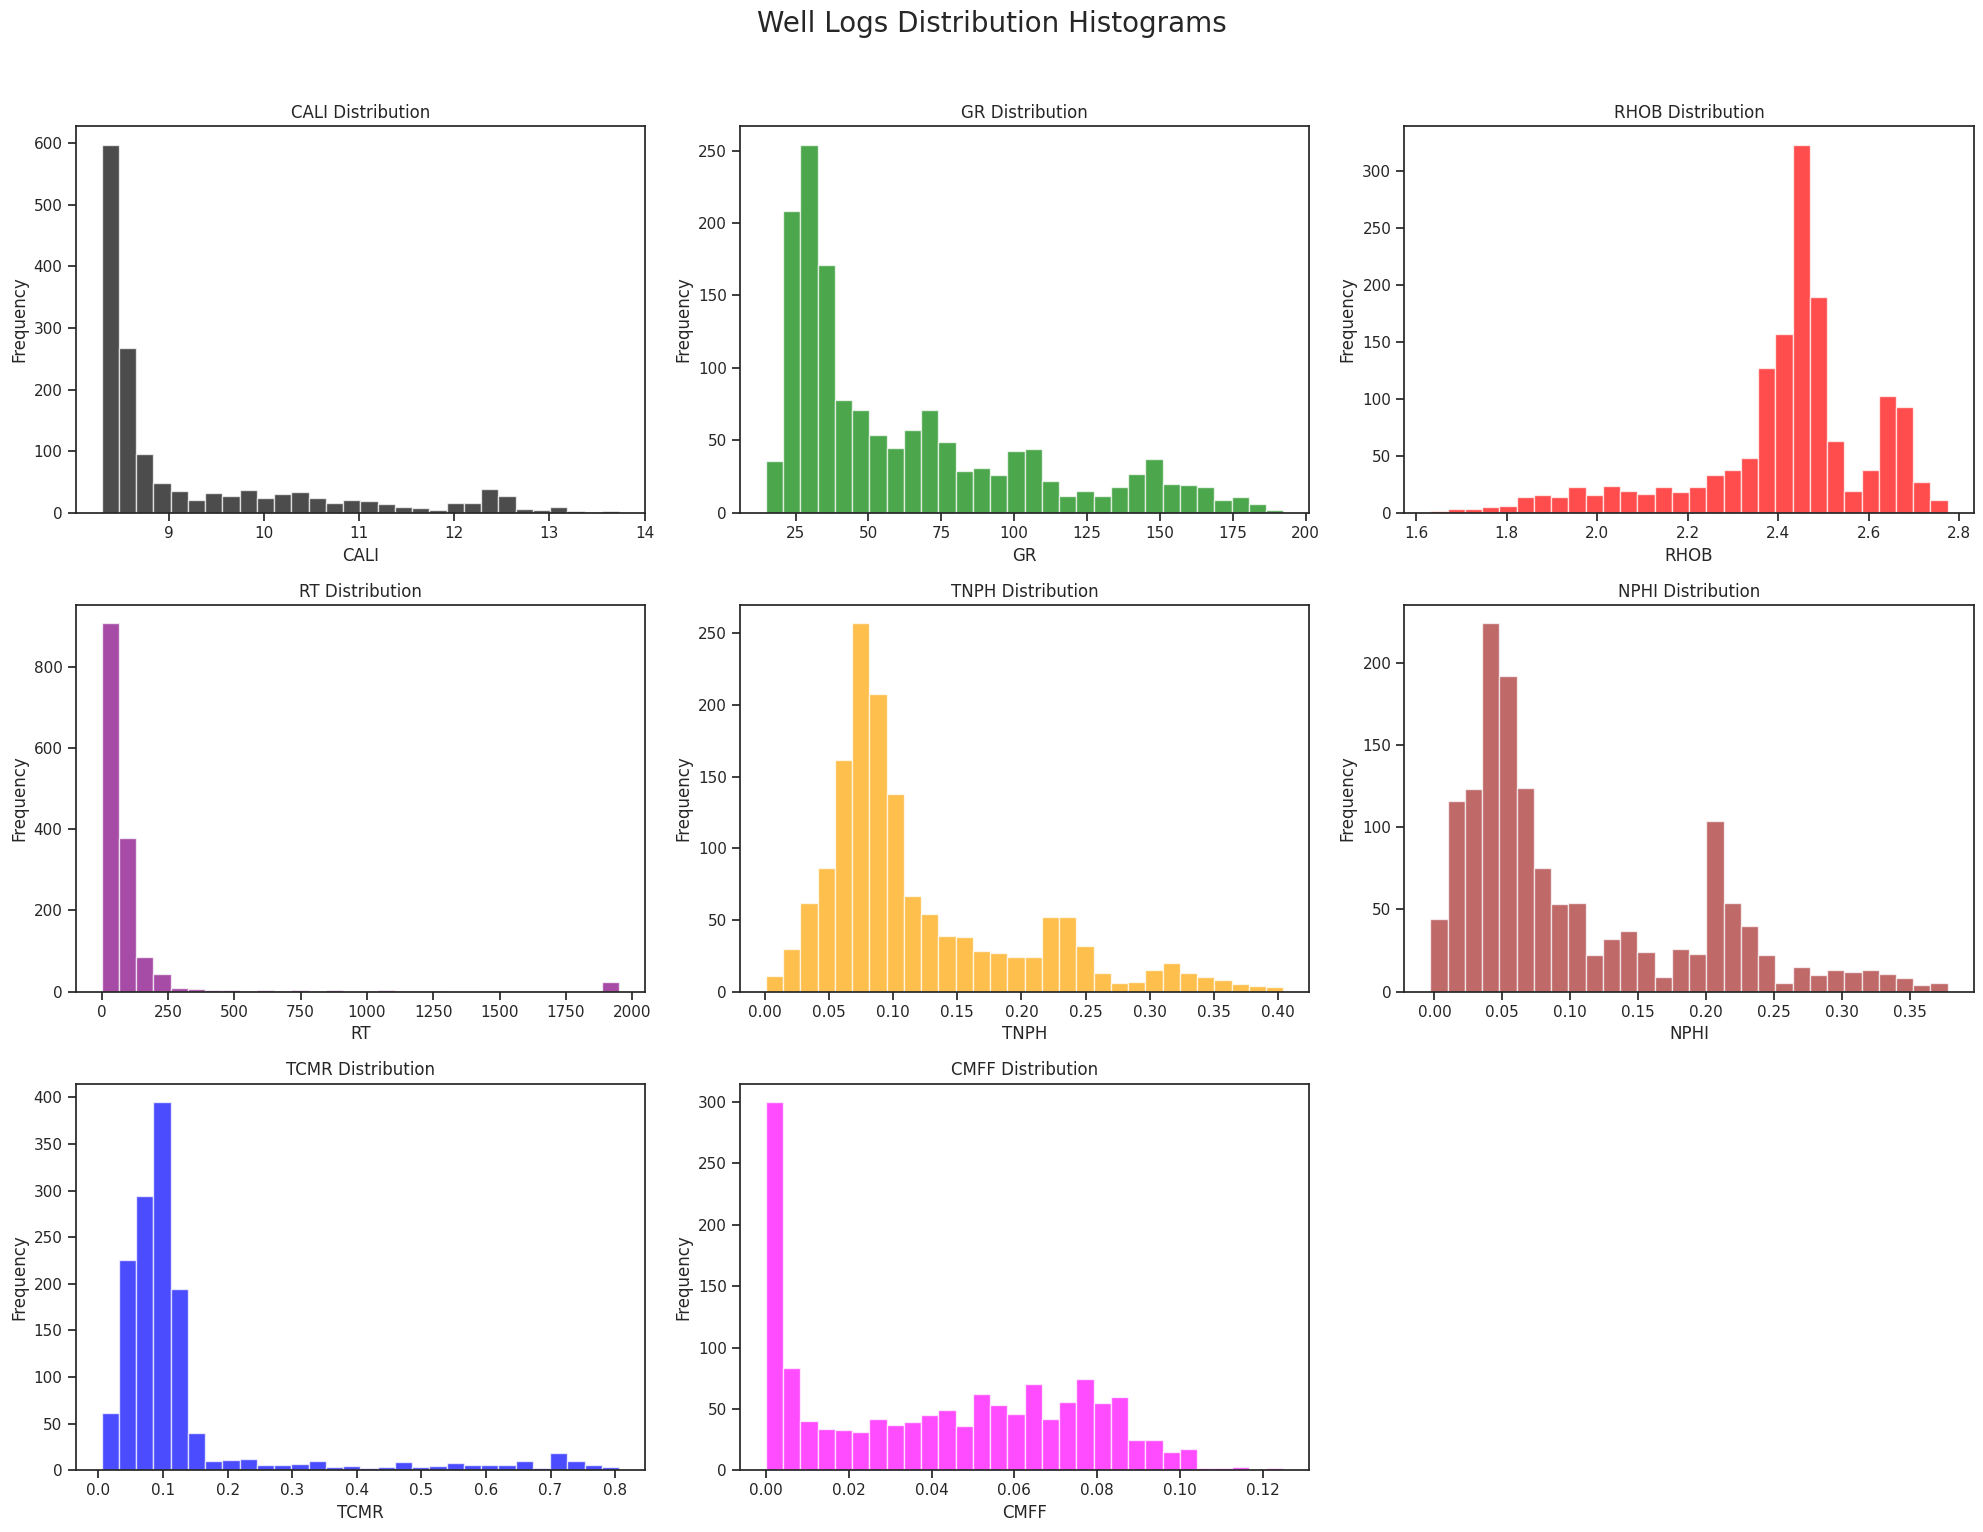

In [63]:
# Histogram for log distribution
plt.figure(figsize=(20, 15))
for i in range(len(logs)):
    plt.subplot(3,3,i+1)
    plt.hist(df[logs[i]].dropna(), bins=30, color=colors[i], alpha=0.7)
    plt.xlabel(logs[i])
    plt.ylabel("Frequency")
    plt.title(f"{logs[i]} Distribution")
plt.suptitle("Well Logs Distribution Histograms", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()